# Final Evaluation — LightGBM on the Held-Out Test Set

This is the third and last notebook of the project.

| Notebook | Purpose |
|---|---|
| `01_data_exploration_and_preprocessing.ipynb` | Load, explore, clean, split and save the data |
| `02_model_training_and_selection.ipynb` | Train four models and compare them by cross-validation |
| **`03_final_evaluation.ipynb`** | **Evaluate the chosen model once on the test set** |

Notebook 02 selected **LightGBM**. This notebook opens the 45,957 held-out records
for the first and only time and measures how the chosen model actually performs on
data that played no part in training it, tuning it, or selecting it.

It produces Figures 10 and 11 and the numbers quoted in Sections 7 and 8 of the report.

## 1. Setup

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, precision_recall_curve,
                             classification_report)
from lightgbm import LGBMClassifier

sns.set_theme(style="whitegrid")
%matplotlib inline
pd.set_option("display.max_columns", None)

print("Libraries loaded.")

Libraries loaded.


In [2]:
data = np.load("brfss_train_test.npz", allow_pickle=True)
X_train, y_train = data["X_train"], data["y_train"]
X_test, y_test = data["X_test"], data["y_test"]
feature_names = list(data["feature_names"])

scale_pos_weight = (y_train == 0).sum() / y_train.sum()

print(f"Training : {X_train.shape[0]:,} rows")
print(f"Testing  : {X_test.shape[0]:,} rows  ({int(y_test.sum()):,} diabetic, "
      f"{int((y_test == 0).sum()):,} non-diabetic)")

Training : 183,824 rows
Testing  : 45,957 rows  (7,945 diabetic, 38,012 non-diabetic)


## 2. Choose the decision threshold — using training data only

The default cut-off of 0.50 is a convention, not an optimum. Before touching the
test set we work out what alternative thresholds would do, using **out-of-fold
predictions on the training set**. Tuning the threshold on the test set would
quietly invalidate the final evaluation, so it is done here instead.

In [3]:
best_model = LGBMClassifier(
    n_estimators=400, learning_rate=0.05, num_leaves=31,
    scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=4, verbose=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_proba = cross_val_predict(best_model, X_train, y_train, cv=cv,
                              method="predict_proba", n_jobs=5)[:, 1]

prec, rec, thr = precision_recall_curve(y_train, oof_proba)
f1_curve = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)

i_f1 = int(np.nanargmax(f1_curve[:-1]))
thr_f1 = float(thr[i_f1])

i_r90 = np.where(rec[:-1] >= 0.90)[0][-1]
thr_r90 = float(thr[i_r90])

print(f"Best-F1 threshold        : {thr_f1:.3f}")
print(f"Threshold for recall 0.90: {thr_r90:.3f}")
print(f"Default                  : 0.500")

Best-F1 threshold        : 0.621
Threshold for recall 0.90: 0.330
Default                  : 0.500


## 3. Train the final model and open the test set

The model is refitted on the entire training set, then applied to the test set once.

In [4]:
final_model = LGBMClassifier(
    n_estimators=400, learning_rate=0.05, num_leaves=31,
    scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=4, verbose=-1,
)
final_model.fit(X_train, y_train)
joblib.dump(final_model, "final_model_lightgbm.joblib")

test_proba = final_model.predict_proba(X_test)[:, 1]

print(f"Test ROC-AUC : {roc_auc_score(y_test, test_proba):.4f}")
print(f"Test PR-AUC  : {average_precision_score(y_test, test_proba):.4f}")

Test ROC-AUC : 0.8142
Test PR-AUC  : 0.4712


In [5]:
def evaluate(threshold, label):
    pred = (test_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {
        "Operating point": label,
        "Threshold": round(threshold, 3),
        "Accuracy": round(accuracy_score(y_test, pred), 4),
        "Balanced acc": round(balanced_accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred), 4),
        "Recall": round(recall_score(y_test, pred), 4),
        "F1": round(f1_score(y_test, pred), 4),
        "Specificity": round(tn / (tn + fp), 4),
        "Missed cases (FN)": int(fn),
        "False alarms (FP)": int(fp),
    }


summary = pd.DataFrame([
    evaluate(thr_r90, "High recall"),
    evaluate(0.50, "Default (recommended)"),
    evaluate(thr_f1, "Best F1"),
]).set_index("Operating point")

summary

,Threshold,Accuracy,Balanced acc,Precision,Recall,F1,Specificity,Missed cases (FN),False alarms (FP)
Operating point,,,,,,,,,
High recall,0.330,0.5936,0.7154,0.2858,0.9016,0.4341,0.5292,782,17896
Default (recommended),0.500,0.7111,0.7355,0.3486,0.7728,0.4805,0.6982,1805,11471
Best F1,0.621,0.7848,0.7201,0.4177,0.6213,0.4996,0.8190,3009,6880


## 4. Confusion matrix at the recommended threshold

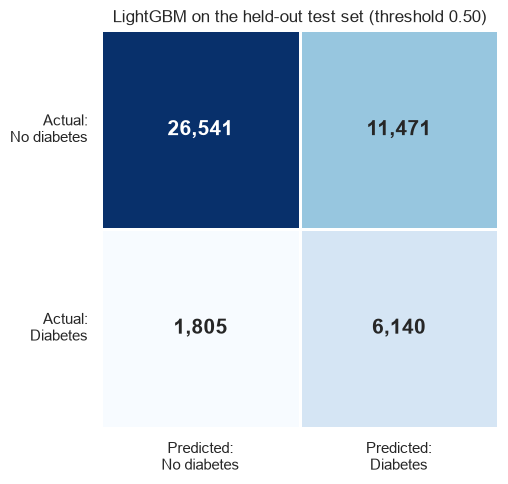

Diabetic people found  : 6,140 of 7,945  (77.3%)
Diabetic people missed : 1,805
Healthy people flagged : 11,471 of 38,012
Total referred to test : 17,611


In [6]:
y_pred = (test_proba >= 0.50).astype(int)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, square=True,
            linewidths=2, annot_kws={"size": 15, "weight": "bold"},
            xticklabels=["Predicted:\nNo diabetes", "Predicted:\nDiabetes"],
            yticklabels=["Actual:\nNo diabetes", "Actual:\nDiabetes"], ax=ax)
ax.set_title("LightGBM on the held-out test set (threshold 0.50)", fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix_test.png", dpi=150)
plt.show()

print(f"Diabetic people found  : {tp:,} of {tp + fn:,}  ({tp / (tp + fn) * 100:.1f}%)")
print(f"Diabetic people missed : {fn:,}")
print(f"Healthy people flagged : {fp:,} of {tn + fp:,}")
print(f"Total referred to test : {tp + fp:,}")

In [7]:
print(classification_report(y_test, y_pred,
                            target_names=["No diabetes", "Diabetes"], digits=4))

              precision    recall  f1-score   support

 No diabetes     0.9363    0.6982    0.7999     38012
    Diabetes     0.3486    0.7728    0.4805      7945

    accuracy                         0.7111     45957
   macro avg     0.6425    0.7355    0.6402     45957
weighted avg     0.8347    0.7111    0.7447     45957



## 5. The threshold trade-off

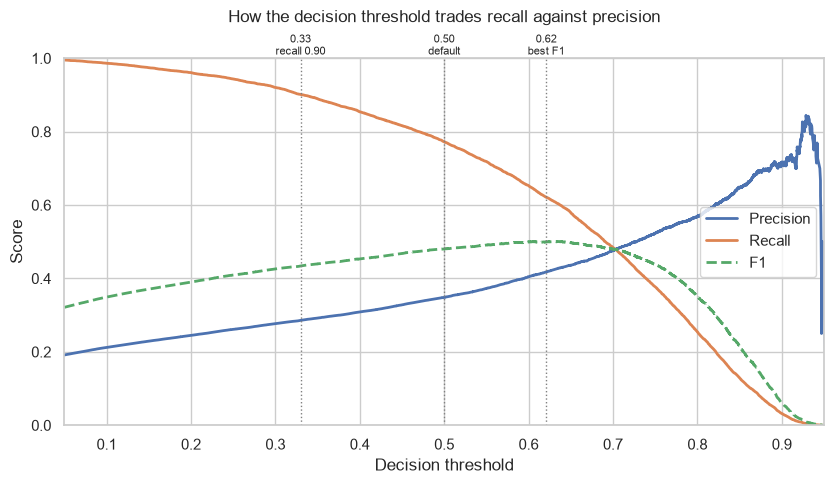

In [8]:
p_t, r_t, t_t = precision_recall_curve(y_test, test_proba)
f1_t = 2 * p_t * r_t / np.clip(p_t + r_t, 1e-12, None)

plt.figure(figsize=(8.5, 5))
plt.plot(t_t, p_t[:-1], label="Precision", linewidth=2)
plt.plot(t_t, r_t[:-1], label="Recall", linewidth=2)
plt.plot(t_t, f1_t[:-1], label="F1", linewidth=2, linestyle="--")
for t, lab in [(thr_r90, "recall 0.90"), (0.5, "default"), (thr_f1, "best F1")]:
    plt.axvline(t, color="grey", linestyle=":", linewidth=1)
    plt.text(t, 1.01, f"{t:.2f}\n{lab}", ha="center", fontsize=8)
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("How the decision threshold trades recall against precision", pad=26)
plt.xlim(0.05, 0.95)
plt.ylim(0, 1)
plt.legend(loc="center right")
plt.tight_layout()
plt.savefig("threshold_tradeoff.png", dpi=150)
plt.show()

## 6. Check against the cross-validated estimate

If the test scores fell well short of the cross-validated ones, it would mean the
model had been over-fitted or that information had leaked from the test set.

In [9]:
cv_scores = pd.read_csv("model_comparison_full.csv", index_col=0).loc["LightGBM"]
test_row = evaluate(0.50, "test")

comparison = pd.DataFrame({
    "Cross-validation": [cv_scores["ROC-AUC"], cv_scores["PR-AUC"],
                         cv_scores["Recall"], cv_scores["Precision"],
                         cv_scores["F1"], cv_scores["Accuracy"]],
    "Test set": [roc_auc_score(y_test, test_proba),
                 average_precision_score(y_test, test_proba),
                 test_row["Recall"], test_row["Precision"],
                 test_row["F1"], test_row["Accuracy"]],
}, index=["ROC-AUC", "PR-AUC", "Recall", "Precision", "F1", "Accuracy"])
comparison["Difference"] = comparison["Test set"] - comparison["Cross-validation"]

comparison.round(4)

,Cross-validation,Test set,Difference
ROC-AUC,0.8088,0.8142,0.0054
PR-AUC,0.4600,0.4712,0.0112
Recall,0.7715,0.7728,0.0013
Precision,0.3458,0.3486,0.0028
F1,0.4776,0.4805,0.0029
Accuracy,0.7082,0.7111,0.0029


In [10]:
results = {
    "best_model": "LightGBM",
    "test_roc_auc": round(roc_auc_score(y_test, test_proba), 4),
    "test_pr_auc": round(average_precision_score(y_test, test_proba), 4),
    "operating_points": summary.reset_index().to_dict(orient="records"),
    "confusion_matrix_at_0.50": {"TN": int(tn), "FP": int(fp),
                                 "FN": int(fn), "TP": int(tp)},
}
with open("final_test_results.json", "w") as f:
    json.dump(results, f, indent=1)

print("Saved final_test_results.json and final_model_lightgbm.joblib")

Saved final_test_results.json and final_model_lightgbm.joblib


---

## Conclusion

LightGBM achieves a **ROC-AUC of 0.814** on records it has never seen, identifying
**77.3%** of diabetic respondents from twenty-one survey answers that require no
laboratory test. The test scores sit marginally *above* the cross-validated
estimates, confirming the model was not over-fitted and that the test set stayed
properly isolated.

The limitation is precision: roughly two in three flagged people do not have
diabetes, so the output is a **referral list, not a diagnosis** — an appropriate
role for a screening instrument, but not a substitute for an HbA1c or fasting
glucose test.

The decision threshold is a policy choice rather than a technical one. Lowering it
to 0.33 would catch 90% of cases but flag almost half the population; raising it to
0.62 scores better on F1 and accuracy while missing considerably more people.